In [1]:
pip install librosa

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio

In [3]:
data_original_rs, sampling_rate_original = librosa.load(librosa.ex('nutcracker'))

C:\ProgramData\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


In [4]:
sampling_rate_original

22050

In [5]:
def get_sign(number):
    if number > 0:
        return 1
    elif number < 0:
        return -1
    else:
        return 0

In [6]:
def zero_crossing_rate(data):
    ZCR_values = []
    paso = 0
    conteo = 0
    conteo_total = 0
    for i in range (len(data)-1):
            paso = paso + 1
        
            temp = data[i] #actual
            temp2 = data[i+1] #siguiente
            if get_sign(temp) != get_sign(temp2):
                
                conteo = conteo + 1
                
            if paso == 441: #FRAME - 20 ms 
                conteo_total = conteo_total + conteo
                zcr_frame = conteo/441
                ZCR_values.append(zcr_frame)
                paso = 0
                conteo = 0
                    
    ZCR = conteo_total/(len(data)-1)
    return conteo_total,ZCR, ZCR_values

In [7]:
values,ZCR,ZCR_values = zero_crossing_rate(data_original_rs)

In [8]:
values

230657

In [9]:
ZCR

0.08726222097460601

In [10]:
ZCR_values[:10]

[0.5918367346938775,
 0.5600907029478458,
 0.562358276643991,
 0.5260770975056689,
 0.546485260770975,
 0.5328798185941043,
 0.5351473922902494,
 0.5238095238095238,
 0.5487528344671202,
 0.5532879818594104]

In [11]:
len(ZCR_values)

5993

In [12]:
len(data_original_rs)

2643264

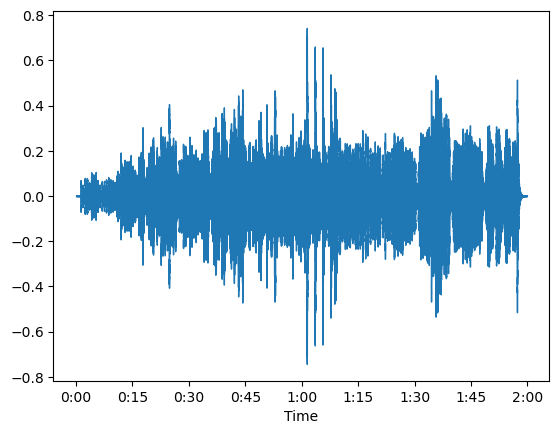

In [13]:
librosa.display.waveshow(data_original_rs, sr=sampling_rate_original)

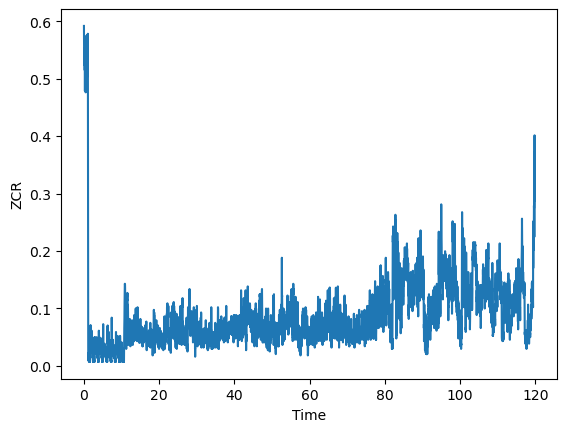

In [14]:
time = [(x*(441/sampling_rate_original)) for x in range(len(ZCR_values))]
plt.plot(time, ZCR_values)
plt.xlabel("Time")
plt.ylabel("ZCR")
plt.show()

In [ ]:
#Que pase mucho por el cero indica que hay mucha frecuencia